Fear and Greed Index:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Historical Data:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       

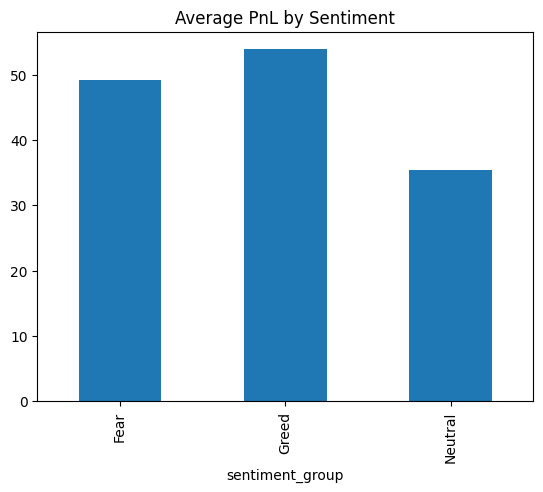

                                      Account        date  Closed PnL
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11         0.0
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17         0.0
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18         0.0
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22    -21227.0
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26      1603.1
                                      Account       win
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914
                                      Account      Size USD
0  0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327
2  0x271b280974205ca63b716753467d5a371de622ab   8893.000898
3  0

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
#load datasets
fear_greed = pd.read_csv('fear_greed_index.csv')
historical = pd.read_csv('historical_data.csv')

print("Fear and Greed Index:")
print(fear_greed.head())
print("\nHistorical Data:")
print(historical.head())

print("\nFear and Greed Shape:", fear_greed.shape)
print("Historical Data Shape:", historical.shape)

print("\nMissing Values in Fear and Greed Index:")
print(fear_greed.isnull().sum())
print("\nMissing Values in Historical Data:")
print(historical.isnull().sum())

print("\nDuplicate Values in Fear and Greed Index:", fear_greed.duplicated().sum())
print("Duplicate Values in Historical Data:", historical.duplicated().sum())

print("\nFear and Greed Columns:",fear_greed.columns)
print("Historical Data Columns:",historical.columns)


# Convert timestamps properly

historical['Timestamp IST'] = pd.to_datetime(historical['Timestamp IST'],dayfirst=True)
historical['date'] = historical['Timestamp IST'].dt.date

fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date

print("Date conversion successful")

merged = pd.merge(historical, fear_greed, on='date', how='left')
print("Merge Successful")
merged['sentiment_group'] = merged['classification'].apply(
    lambda x: 'Fear' if 'Fear' in str(x)
    else 'Greed' if 'Greed' in str(x)
    else 'Neutral'
)
# Average PnL
pnl_by_sentiment = merged.groupby('sentiment_group')['Closed PnL'].mean()
print("\nAverage PnL by Sentiment:")
print(pnl_by_sentiment)

# Win rate
merged['win'] = merged['Closed PnL'] > 0
from sklearn.cluster import KMeans

# Create trader-level features
trader_features = merged.groupby('Account').agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean',
    'win': 'mean'
}).dropna()

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(trader_features)

# View cluster characteristics
print("\nCluster Summary:")
print(trader_features.groupby('cluster').mean())
winrate_by_sentiment = merged.groupby('sentiment_group')['win'].mean()
print("\nWin Rate by Sentiment:")
print(winrate_by_sentiment)
drawdown_proxy = merged.groupby('sentiment_group')['Closed PnL'].min()

print("\nWorst Trade (Drawdown Proxy):")
print(drawdown_proxy)

# Trade frequency
trade_count = merged.groupby('sentiment_group').size()
print("\nTrade Count by Sentiment:")
print(trade_count)

# Average trade size
size_by_sentiment = merged.groupby('sentiment_group')['Size USD'].mean()
print("\nAverage Trade Size by Sentiment:")
print(size_by_sentiment)

direction_sentiment = pd.crosstab(
    merged['sentiment_group'],
    merged['Direction'],
    normalize='index'
)

print("\nLong/Short Ratio by Sentiment:")
print(direction_sentiment)

trade_counts = merged.groupby('Account').size()

threshold = trade_counts.median()

merged['frequency_segment'] = merged['Account'].map(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)

avg_size = merged.groupby('Account')['Size USD'].mean()

size_threshold = avg_size.median()

merged['size_segment'] = merged['Account'].map(
    lambda x: 'High Size' if avg_size[x] > size_threshold else 'Low Size'
)

win_rate_account = merged.groupby('Account')['win'].mean()

merged['performance_segment'] = merged['Account'].map(
    lambda x: 'Consistent Winner' if win_rate_account[x] > 0.6 else 'Inconsistent'
)

pnl_by_sentiment.plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.show()

daily_pnl=historical.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
print(daily_pnl.head())

historical['win']=historical['Closed PnL']>0
win_rate=historical.groupby('Account')['win'].mean().reset_index()
print(win_rate.head())

avg_trade_size=historical.groupby('Account')['Size USD'].mean().reset_index()
print(avg_trade_size.head())

trades_per_day=historical.groupby(['Account','date']).size().reset_index(name='num_trades')
print(trades_per_day.head())

print(historical['Side'].value_counts())
print(historical['Direction'].value_counts())
long_short_ratio = historical['Direction'].value_counts(normalize=True)

print(long_short_ratio)
print(historical.columns)
print("\nTrade Size Distribution (USD):")
print(historical['Size USD'].describe())
print("\nTop Trade Sizes:")
print(historical['Size USD'].value_counts().head())